# Exploratory Data Analysis (EDA) - Student Feedback Sentiment Analysis

Notebook này thực hiện phân tích dữ liệu khám phá (EDA) cho tập dữ liệu phản hồi của sinh viên.

## 1️⃣ Load & Clean Data

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
sns.set_style("whitegrid")
plt.rcParams['font.size'] = 12
plt.rcParams['figure.figsize'] = (10, 6)

# Define paths - using relative path from notebook location
# Adjust base path according to your environment
if Path('/content/data').exists():
    # Google Colab environment
    DATA_DIR = Path('/content/data')
else:
    # Local environment
    DATA_DIR = Path('../data/raw')  # Path from notebook/ to data/raw/

TRAIN_DIR = DATA_DIR / 'train'
VAL_DIR = DATA_DIR / 'validation'
TEST_DIR = DATA_DIR / 'test'

# Define labels
SENTIMENT_LABELS = {
    0: 'Negative',
    1: 'Neutral',
    2: 'Positive'
}

ASPECT_LABELS = {
    0: 'Giảng viên',
    1: 'Chương trình môn học',
    2: 'Cơ sở vật chất',
    3: 'Khác'
}

In [32]:
def load_data(split='train'):
    """
    Load data from a specific split (train/validation/test)

    Returns:
        pd.DataFrame: DataFrame with columns: sentence, sentiment, aspect
    """
    data_dir = DATA_DIR / split

    # Load sentences
    with open(data_dir / 'sents.txt', 'r', encoding='utf-8') as f:
        sentences = [line.strip() for line in f if line.strip()]

    # Load sentiments
    with open(data_dir / 'sentiments.txt', 'r', encoding='utf-8') as f:
        sentiments = [int(line.strip()) for line in f if line.strip()]

    # Load topics/aspects
    with open(data_dir / 'topics.txt', 'r', encoding='utf-8') as f:
        aspects = [int(line.strip()) for line in f if line.strip()]

    # Create DataFrame
    df = pd.DataFrame({
        'sentence': sentences,
        'sentiment': sentiments,
        'aspect': aspects
    })

    return df

# Load all splits
train_df = load_data('train')
val_df = load_data('validation')
test_df = load_data('test')

# Combine for EDA
df = pd.concat([train_df, val_df, test_df], ignore_index=True)

print(f"Train samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")
print(f"Total samples: {len(df)}")

df.head()

Train samples: 11426
Validation samples: 1583
Test samples: 3166
Total samples: 16175


,sentence,sentiment,aspect
0,slide giáo trình đầy đủ .,2,1
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2,0
2,đi học đầy đủ full điểm chuyên cần .,0,1
3,chưa áp dụng công nghệ thông tin và các thiết ...,0,0
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",2,0


In [33]:
# Data cleaning
print('Missing values:')
print(df.isnull().sum())

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")

# Remove duplicates if any
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Removed {duplicates} duplicate rows")

Missing values:
sentence     0
sentiment    0
aspect       0
dtype: int64

Duplicate rows: 0


## 2️⃣ Save Cleaned Data

In [34]:
def save_processed_data(df, split='train'):
    """
    Save processed data to data/processed directory

    Args:
        df: DataFrame with columns: sentence, sentiment, aspect
        split: 'train', 'validation', or 'test'
    """
    # Define output directory - use absolute path from notebook location
    notebook_dir = Path.cwd()  # Get current working directory
    if 'notebook' in str(notebook_dir):
        # Running from notebook/ directory
        base_dir = notebook_dir.parent
    else:
        # Running from other location, go up from notebook/
        base_dir = notebook_dir / '..' / '..'
    
    output_dir = base_dir.resolve() / 'data' / 'processed' / split
    output_dir.mkdir(parents=True, exist_ok=True)

    print(f'Saving to: {output_dir}')

    # Save sentences
    with open(output_dir / 'sents.txt', 'w', encoding='utf-8') as f:
        for sentence in df['sentence']:
            f.write(f'{sentence}\n')

    # Save sentiments
    with open(output_dir / 'sentiments.txt', 'w', encoding='utf-8') as f:
        for sentiment in df['sentiment']:
            f.write(f'{sentiment}\n')

    # Save topics/aspects
    with open(output_dir / 'topics.txt', 'w', encoding='utf-8') as f:
        for aspect in df['aspect']:
            f.write(f'{aspect}\n')

    print(f'✅ Saved {len(df)} samples to {output_dir}')

# Save all splits
save_processed_data(train_df, 'train')
save_processed_data(val_df, 'validation')
save_processed_data(test_df, 'test')

print('\n📁 Processed data structure:')
print('data/processed/')
print('├── train/')
print('│   ├── sents.txt')
print('│   ├── sentiments.txt')
print('│   └── topics.txt')
print('├── validation/')
print('│   ├── sents.txt')
print('│   ├── sentiments.txt')
print('│   └── topics.txt')
print('└── test/')
print('    ├── sents.txt')
print('    ├── sentiments.txt')
print('    └── topics.txt')

Saving to: F:\My Drive\Student-Feedback-Sentiment-Analysis\data\processed\train
✅ Saved 11426 samples to F:\My Drive\Student-Feedback-Sentiment-Analysis\data\processed\train
Saving to: F:\My Drive\Student-Feedback-Sentiment-Analysis\data\processed\validation
✅ Saved 1583 samples to F:\My Drive\Student-Feedback-Sentiment-Analysis\data\processed\validation
Saving to: F:\My Drive\Student-Feedback-Sentiment-Analysis\data\processed\test
✅ Saved 3166 samples to F:\My Drive\Student-Feedback-Sentiment-Analysis\data\processed\test

📁 Processed data structure:
data/processed/
├── train/
│   ├── sents.txt
│   ├── sentiments.txt
│   └── topics.txt
├── validation/
│   ├── sents.txt
│   ├── sentiments.txt
│   └── topics.txt
└── test/
    ├── sents.txt
    ├── sentiments.txt
    └── topics.txt


In [35]:
# Add text length column
df['text_length'] = df['sentence'].str.split().str.len()

# Add sentiment labels
df['sentiment_label'] = df['sentiment'].map(SENTIMENT_LABELS)

# Add aspect labels
df['aspect_label'] = df['aspect'].map(ASPECT_LABELS)

df.head()

,sentence,sentiment,aspect,text_length,sentiment_label,aspect_label
0,slide giáo trình đầy đủ .,2,1,6,Positive,Chương trình môn học
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2,0,11,Positive,Giảng viên
2,đi học đầy đủ full điểm chuyên cần .,0,1,9,Negative,Chương trình môn học
3,chưa áp dụng công nghệ thông tin và các thiết ...,0,0,18,Negative,Giảng viên
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",2,0,15,Positive,Giảng viên


## 2️⃣ Thống kê tổng quan

In [36]:
# Calculate overview statistics
total_responses = len(df)
total_sentences = len(df)
total_aspects = df['aspect'].nunique()
total_sentiment_classes = df['sentiment'].nunique()
avg_words_per_sentence = df['text_length'].mean()
max_length = df['text_length'].max()
min_length = df['text_length'].min()

# Create summary table
summary_table = pd.DataFrame({
    'Thống kê': [
        'Tổng số phản hồi',
        'Số câu',
        'Số khía cạnh',
        'Số lớp cảm xúc',
        'Trung bình số từ / câu',
        'Max / Min độ dài câu'
    ],
    'Giá trị': [
        total_responses,
        total_sentences,
        total_aspects,
        total_sentiment_classes,
        f'{avg_words_per_sentence:.2f}',
        f'{max_length} / {min_length}'
    ]
})

summary_table

,Thống kê,Giá trị
0,Tổng số phản hồi,16175
1,Số câu,16175
2,Số khía cạnh,4
3,Số lớp cảm xúc,3
4,Trung bình số từ / câu,14.23
5,Max / Min độ dài câu,161 / 2


## 3️⃣ Sentiment Distribution

In [37]:
# Calculate sentiment distribution
sentiment_counts = df['sentiment_label'].value_counts().sort_index()
sentiment_pct = (sentiment_counts / len(df) * 100).round(2)

# Create sentiment distribution table
sentiment_table = pd.DataFrame({
    'Sentiment': sentiment_counts.index,
    'Số lượng': sentiment_counts.values,
    'Tỷ lệ (%)': sentiment_pct.values
})

sentiment_table

,Sentiment,Số lượng,Tỷ lệ (%)
0,Negative,7439,45.99
1,Neutral,698,4.32
2,Positive,8038,49.69


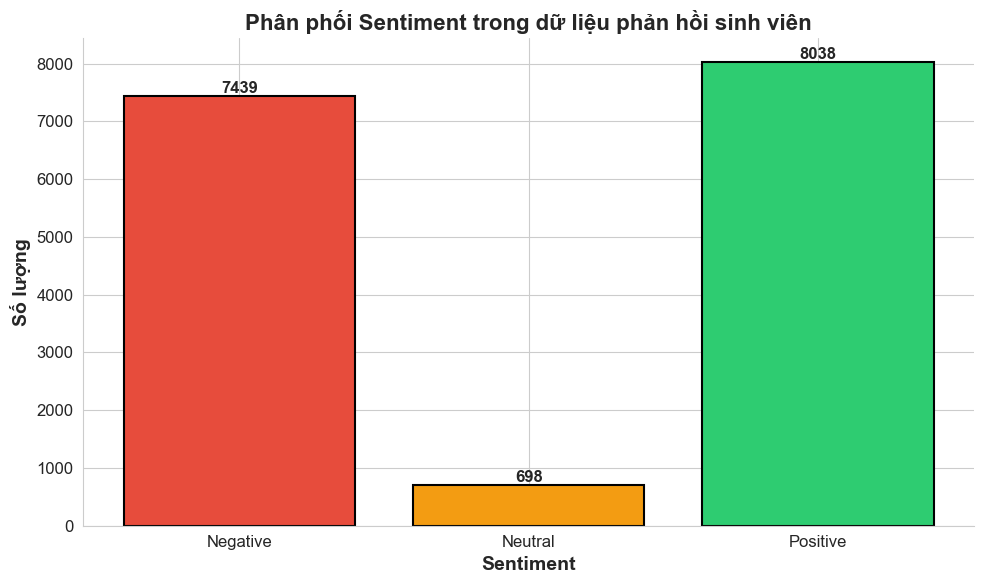

In [38]:
# Bar chart for sentiment distribution
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c', '#f39c12', '#2ecc71']  # Red, Orange, Green
bars = ax.bar(sentiment_table['Sentiment'], sentiment_table['Số lượng'], color=colors, edgecolor='black', linewidth=1.5)

# Add count labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_xlabel('Sentiment', fontsize=14, fontweight='bold')
ax.set_ylabel('Số lượng', fontsize=14, fontweight='bold')
ax.set_title('Phân phối Sentiment trong dữ liệu phản hồi sinh viên', fontsize=16, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 4️⃣ Aspect Distribution (ACSA)

In [39]:
# Calculate aspect distribution
aspect_counts = df['aspect_label'].value_counts().sort_index()

# Create aspect distribution table
aspect_table = pd.DataFrame({
    'Aspect': aspect_counts.index,
    'Số lượng': aspect_counts.values
})

aspect_table

,Aspect,Số lượng
0,Chương trình môn học,3040
1,Cơ sở vật chất,712
2,Giảng viên,11607
3,Khác,816


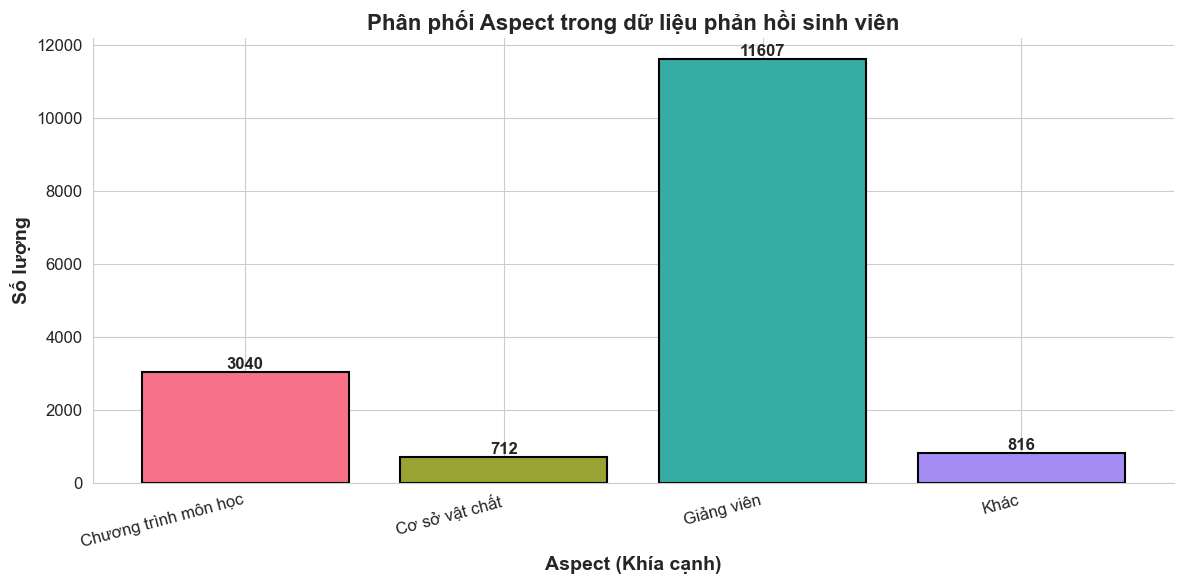

In [40]:
# Bar chart for aspect distribution
fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette('husl', len(aspect_table))
bars = ax.bar(aspect_table['Aspect'], aspect_table['Số lượng'], color=colors, edgecolor='black', linewidth=1.5)

# Add count labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_xlabel('Aspect (Khía cạnh)', fontsize=14, fontweight='bold')
ax.set_ylabel('Số lượng', fontsize=14, fontweight='bold')
ax.set_title('Phân phối Aspect trong dữ liệu phản hồi sinh viên', fontsize=16, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=15, ha='right')

plt.tight_layout()
plt.show()

## 5️⃣ Độ dài câu (Text Length Distribution)

In [41]:
# Calculate statistics for text length
print('Thống kê độ dài câu:')
print(df['text_length'].describe())

print(f"\nMedian: {df['text_length'].median()}")
print(f"Mode: {df['text_length'].mode()[0]}")

Thống kê độ dài câu:
count    16175.000000
mean        14.229181
std         10.103769
min          2.000000
25%          8.000000
50%         11.000000
75%         17.000000
max        161.000000
Name: text_length, dtype: float64

Median: 11.0
Mode: 8


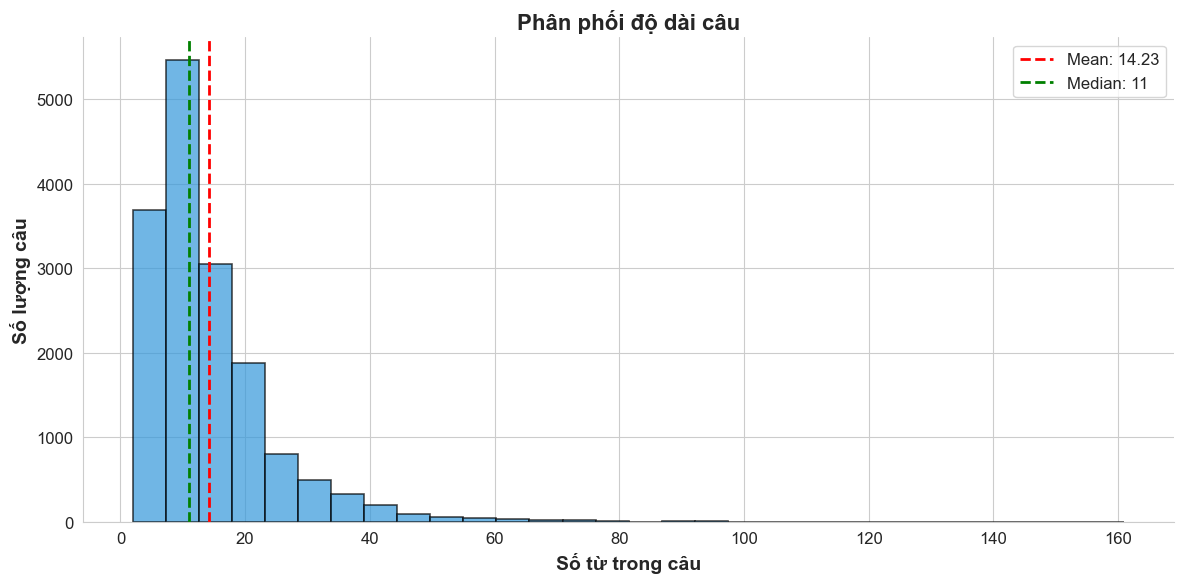

In [42]:
# Histogram for text length distribution
fig, ax = plt.subplots(figsize=(12, 6))

n, bins, patches = ax.hist(df['text_length'], bins=30, color='#3498db', edgecolor='black', linewidth=1.2, alpha=0.7)

# Add mean and median lines
mean_length = df['text_length'].mean()
median_length = df['text_length'].median()

ax.axvline(mean_length, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_length:.2f}')
ax.axvline(median_length, color='green', linestyle='--', linewidth=2, label=f'Median: {median_length:.0f}')

ax.set_xlabel('Số từ trong câu', fontsize=14, fontweight='bold')
ax.set_ylabel('Số lượng câu', fontsize=14, fontweight='bold')
ax.set_title('Phân phối độ dài câu', fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 6️⃣ Sentiment × Aspect Cross-Tabulation

In [43]:
# Create cross-tabulation of sentiment by aspect
sentiment_aspect_crosstab = pd.crosstab(
    df['aspect_label'],
    df['sentiment_label'],
    margins=True,
    margins_name='Total'
)

# Reorder columns to match expected order
sentiment_aspect_crosstab = sentiment_aspect_crosstab[['Positive', 'Negative', 'Neutral', 'Total']]

sentiment_aspect_crosstab

sentiment_label,Positive,Negative,Neutral,Total
aspect_label,,,,
Chương trình môn học,550,2328,162,3040
Cơ sở vật chất,18,681,13,712
Giảng viên,7210,4105,292,11607
Khác,260,325,231,816
Total,8038,7439,698,16175


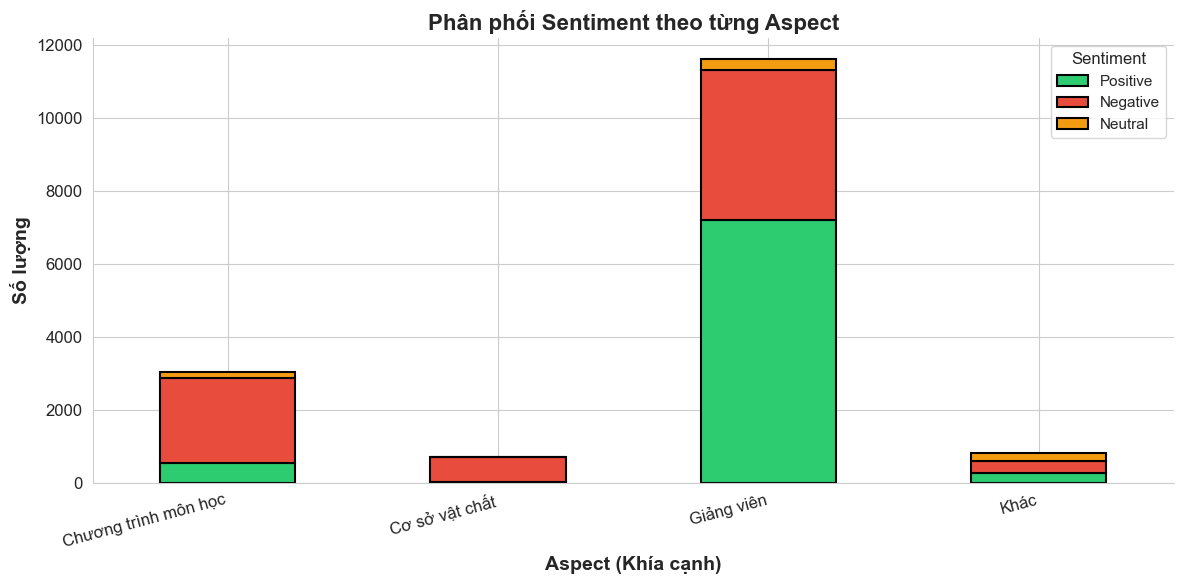

In [44]:
# Stacked bar chart for sentiment by aspect
fig, ax = plt.subplots(figsize=(12, 6))

# Remove 'Total' row for plotting
plot_data = sentiment_aspect_crosstab.drop('Total')

# Define colors for sentiments
colors = {'Positive': '#2ecc71', 'Negative': '#e74c3c', 'Neutral': '#f39c12'}

# Create stacked bar chart
plot_data[['Positive', 'Negative', 'Neutral']].plot(
    kind='bar',
    stacked=True,
    color=[colors['Positive'], colors['Negative'], colors['Neutral']],
    edgecolor='black',
    linewidth=1.5,
    ax=ax
)

ax.set_xlabel('Aspect (Khía cạnh)', fontsize=14, fontweight='bold')
ax.set_ylabel('Số lượng', fontsize=14, fontweight='bold')
ax.set_title('Phân phối Sentiment theo từng Aspect', fontsize=16, fontweight='bold')
ax.legend(title='Sentiment', fontsize=11, title_fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=15, ha='right')

plt.tight_layout()
plt.show()

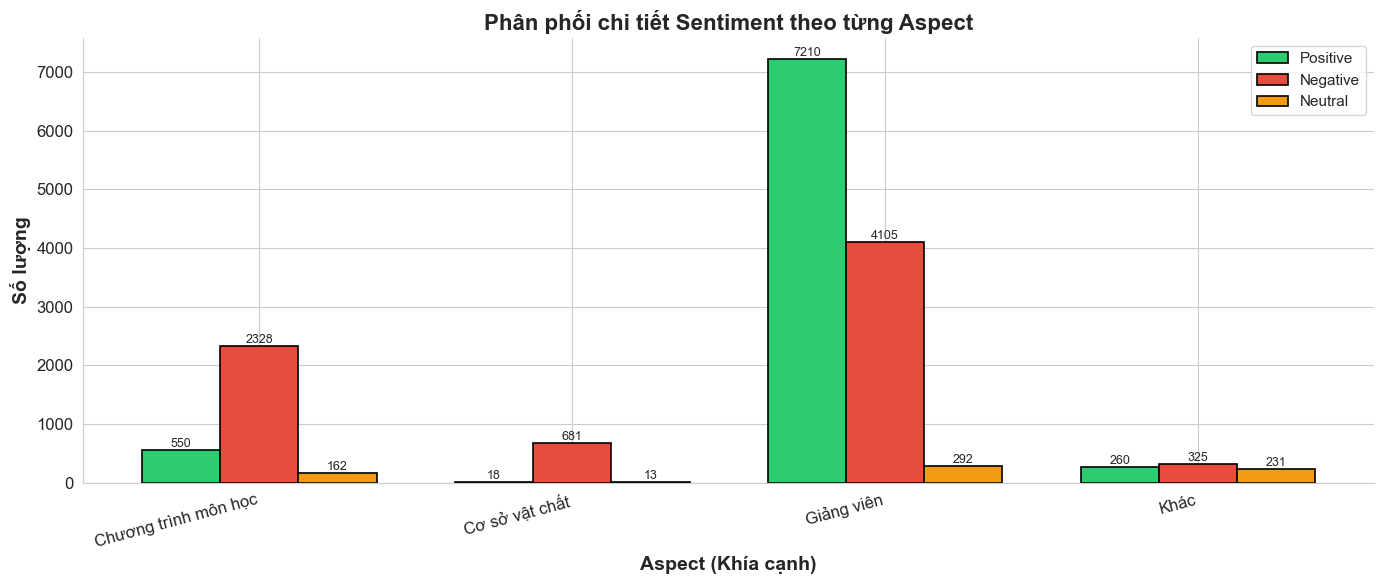

In [45]:
# Grouped bar chart for better comparison
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(plot_data.index))
width = 0.25

sentiments = ['Positive', 'Negative', 'Neutral']
colors = ['#2ecc71', '#e74c3c', '#f39c12']

for i, sentiment in enumerate(sentiments):
    offset = (i - 1) * width
    bars = ax.bar(x + offset, plot_data[sentiment], width,
                  label=sentiment, color=colors[i], edgecolor='black', linewidth=1.2)

    # Add count labels on bars
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}',
                    ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Aspect (Khía cạnh)', fontsize=14, fontweight='bold')
ax.set_ylabel('Số lượng', fontsize=14, fontweight='bold')
ax.set_title('Phân phối chi tiết Sentiment theo từng Aspect', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(plot_data.index, rotation=15, ha='right')
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 📊 Summary

Notebook này đã thực hiện phân tích dữ liệu khám phá (EDA) đầy đủ cho tập dữ liệu phản hồi của sinh viên với:

1. ✅ **Load & Clean Data**: Đã load và làm sạch dữ liệu từ train/validation/test
2. ✅ **Thống kê tổng quan**: Bảng tổng quan về số lượng mẫu, khía cạnh, lớp cảm xúc, và độ dài câu
3. ✅ **Sentiment Distribution**: Phân tích phân phối sentiment (Positive/Negative/Neutral)
4. ✅ **Aspect Distribution**: Phân tích phân phối aspect (Giảng viên/Chương trình môn học/Cơ sở vật chất/Khác)
5. ✅ **Text Length Distribution**: Phân tích độ dài câu qua histogram
6. ✅ **Sentiment × Aspect**: Cross-tabulation và visualization chi tiết
